# 04 Multi-Criteria Integration — Weighted Linear Combination

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Advisor: Patrick Laube

Combines 10 normalized suitability factors (F01–F10) from Notebook 03 using weighted linear combination (WLC).

**Input:**
```
data/processed/criteria/f01_globalstrahlung.tif  … f10_sichtbarkeit.tif
data/processed/constraints/constraint_mask_s2.tif
```

**Output:**
```
outputs/suitability_wlc.tif          (continous 0–1)
outputs/suitability_classes.tif       (5 classes)
outputs/figures/suitability_map.png
outputs/tables/suitability_stats.csv
```

## 1. Setup & Imports

In [1]:
from pathlib import Path                                                   # Cross-platform file path handling
import geopandas as gpd                                                    # Geospatial vector data manipulation
import numpy as np                                                         # Numerical array operations and math
import pandas as pd                                                        # Tabular data handling and analysis
import rasterio                                                            # Read/write raster GIS data (GeoTIFF)
import matplotlib.pyplot as plt                                            # Plotting and visualization library
from matplotlib.colors import BoundaryNorm, ListedColormap                # Custom colormaps and color normalization
import warnings
warnings.filterwarnings("ignore")                                          # Suppress non-critical warnings

# Load data paths
RAW  = Path("../data/raw")                                                # Raw input data directory
PROC = Path("../data/processed")                                           # Processed data directory
OUT  = Path("../outputs")                                                  # Output directory
for d in [OUT, OUT / "figures", OUT / "tables"]:
    d.mkdir(parents=True, exist_ok=True)                                   # Create output subdirectories if not existing

# Define constants
CRS    = "EPSG:2056"                                                       # Target CRS (LV95, Swiss standard coordinate system)
NODATA = -9999.0                                                           # NoData value for raster pixels

print("✓ Setup OK")

✓ Setup OK


## Höhenlage 1 mal 1400-2500 und hier 1800-2500?????? Stöf???????

# Allgemein Stimmen Quellen und Daten/Infos? bzw über gleich in Notebooks?

## 2. Weights

Adjust AHP weights here. **Sum must equal 1.0.**

| ID | Criterion | Source |
|---|---|---|
| F01 | Global Radiation Annual Sum | Kahl et al. (2019) |
| F02 | Winter Radiation Oct–Mar | Art. 71a EnG, Frischholz et al. (2024) |
| F03 | Slope (Optimum 20–30°) | Swissolar (2025) 4.1.1 |
| F04 | Aspect (South Deviation) | Kahl et al. (2019) |
| F05 | Elevation (1800–2500 m) | Kahl et al. (2019) |
| F06 | Snow Cover (SCD) | Kahl et al. (2019) |
| F07 | Distance to Grid Connection | Swissolar (2025) 4.1.6 |
| F08 | Distance to Roads | Dujardin et al. (2022) |
| F09 | Proximity to Infrastructure | Swissolar (2025) 4.1.6 + 4.2.1 |
| F10 | Visibility | Swissolar (2025) 4.2.1 |

In [2]:
# Adjust weights here (sum must = 1.0)
WEIGHTS = {
    "f01_globalstrahlung":     0.25,                                       # Global radiation annual sum
    "f02_wintereinstrahlung":  0.10,                                       # Winter radiation Oct–Mar
    "f03_hangneigung":         0.12,                                       # Slope (optimum 20–30°)
    "f04_exposition":          0.12,                                       # Aspect (south deviation)
    "f05_hoehenlage":          0.10,                                       # Elevation (1800–2500 m)
    "f06_schneebedeckung":     0.06,                                       # Snow cover (SCD)
    "f07_netzanschluss":       0.08,                                       # Distance to grid connection
    "f08_strasse":             0.07,                                       # Distance to roads
    "f09_infrastruktur":       0.05,                                       # Proximity to infrastructure
    "f10_sichtbarkeit":        0.05,                                       # Visibility
}

# Define suitability classes (thresholds adjustable)
CLASSES = {
    1: (0.0, 0.6, "Unsuitable or Low suitability"),
    2: (0.6, 0.7, "Moderate suitability"),
    3: (0.7, 0.8, "Suitable"),
    4: (0.8, 0.9, "Well suited"),
    5: (0.9, 1.0, "Very well suited"),#
}

# Validate weights
w_sum = sum(WEIGHTS.values()) #calculate sum of weights
assert abs(w_sum - 1.0) < 1e-6, f"Weights do not sum to 1.0 ({w_sum:.6f})!"# Check if weights sum to 1.0 (allowing for floating-point precision)
print(f"✓ Weights OK (Sum: {w_sum:.4f})\n")# Print weights and their corresponding bar charts
for name, w in WEIGHTS.items():
    bar = "█" * int(w * 50)                                                # Bar chart visualization
    print(f"  {name:30s} {w:.2f}  {bar}")

✓ Weights OK (Sum: 1.0000)

  f01_globalstrahlung            0.25  ████████████
  f02_wintereinstrahlung         0.10  █████
  f03_hangneigung                0.12  ██████
  f04_exposition                 0.12  ██████
  f05_hoehenlage                 0.10  █████
  f06_schneebedeckung            0.06  ███
  f07_netzanschluss              0.08  ████
  f08_strasse                    0.07  ███
  f09_infrastruktur              0.05  ██
  f10_sichtbarkeit               0.05  ██


## 3. Functions

In [3]:
def load_criteria(criteria_dir, weight_dict, nodata): #define function to load criteria rasters
    """Load all criteria rasters and return arrays + profile."""
    rasters = {}#rasters dictionary to store loaded raster data   
    profile = None# Loop through criteria, load rasters, and check value ranges
    for name in weight_dict:# Loop through criteria names defined in weight_dict
        path = criteria_dir / f"{name}.tif"# Construct file path for the criterion raster
        if not path.exists():# Check if the file exists, if not raise an error
            raise FileNotFoundError(f"Criterion missing: {path}")# Load raster data
        with rasterio.open(path) as src:# Open the raster file
            data = src.read(1)                                             # Read band 1
            if profile is None:
                profile = src.profile.copy()                               # Reference profile
        rasters[name] = data# Store raster data in dictionary
        v = data[data != nodata]                                           # Valid pixels
        print(f"  {name:30s}  min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}")
        if v.min() < -0.01 or v.max() > 1.01:                             # Check value range
            print(f"    ⚠ Values outside [0, 1]!")
    return rasters, profile


def compute_wlc(rasters, weight_dict, valid_mask, nodata):#compute_wlc function to calculate the weighted linear combination of criteria rasters
    """Compute weighted linear combination (WLC)."""
    h, w = valid_mask.shape# Get dimensions from validity mask
    result = np.full((h, w), nodata, dtype=np.float32)                     # Initialize result array
    weighted_sum = np.zeros((h, w), dtype=np.float64)                      # Accumulator
    all_valid = valid_mask.copy()                                          # Validity mask

    for name, weight in weight_dict.items():# Loop through criteria and compute weighted sum
        data = rasters[name]# Get raster data for this criterion
        all_valid &= (data != nodata)                                      # Only where all criteria valid
        weighted_sum += weight * np.where(data != nodata, data, 0)         # Weighted sum

    result[all_valid] = weighted_sum[all_valid].astype(np.float32)         # Write result
    return result


def classify_suitability(suitability, class_dict, valid_mask, nodata):#classify_suitability function to convert continuous suitability scores into discrete classes
    """Split continuous score into discrete suitability classes."""
    classified = np.full(suitability.shape, 0, dtype=np.uint8)             # 0 = NoData
    m = valid_mask & (suitability != nodata)                               # Valid pixels
    for cls_id, (lo, hi, _) in class_dict.items():# Loop through classes and assign class IDs based on thresholds
        in_class = m & (suitability >= lo) & (suitability < hi)            # Assign class
        classified[in_class] = cls_id# Handle upper bound (suitability == 1.0) → assign to highest class
    max_cls = max(class_dict.keys())
    classified[m & (suitability >= 1.0)] = max_cls                         # Upper bound → highest class
    return classified


def compute_statistics(suitability, classified, class_dict, valid_mask, nodata, res):#compute_statistics function to calculate area statistics for each suitability class
    """Compute area statistics per suitability class."""
    m = valid_mask & (suitability != nodata)# Valid pixels mask
    pixel_area_km2 = (res * res) / 1e6                                     # Pixel area in km²
    rows = []# Loop through classes and compute statistics
    for cls_id, (lo, hi, label) in class_dict.items():# Create mask for this class
        mask_cls = m & (classified == cls_id)# Count pixels and compute stats
        n = mask_cls.sum()                                                 # Pixels of this class
        vals = suitability[mask_cls]# Suitability values for this class
        rows.append({
            "Class": cls_id, "Label": label, "Range": f"{lo:.1f}–{hi:.1f}",# Class ID, label, and range
            "Pixels": n, "Area_km2": round(n * pixel_area_km2, 2),# Area in km²
            "Share_%": round(100 * n / m.sum(), 1) if m.sum() > 0 else 0,# Share of valid area
            "Mean": round(vals.mean(), 3) if n > 0 else None,# Mean suitability for this class
            "Std": round(vals.std(), 3) if n > 0 else None,# Std deviation for this class
        })
    # Total row
    total_n = m.sum()# Total valid pixels
    rows.append({
        "Class": "", "Label": "TOTAL", "Range": "0.0–1.0",# Total row with overall stats
        "Pixels": total_n, "Area_km2": round(total_n * pixel_area_km2, 2),# Total area
        "Share_%": 100.0,
        "Mean": round(suitability[m].mean(), 3),# Mean suitability for total
        "Std": round(suitability[m].std(), 3),# Std deviation for total
    })
    return pd.DataFrame(rows)


def save_raster(data, path, profile, dtype="float32", nodata_val=None):#save raster function to write output GeoTIFF files
    """Save raster as compressed GeoTIFF."""
    p = profile.copy()
    p.update(dtype=dtype, count=1, compress="deflate")                     # Deflate compression
    if nodata_val is not None:# Update NoData value if provided
        p.update(nodata=nodata_val)#update profile with nodata value
    with rasterio.open(path, "w", **p) as dst:# Open file for writing
        dst.write(data.astype(dtype), 1)                                   # Write band 1
    print(f"  ✓ {path}")


def plot_suitability(suitability, classified, class_dict, valid_mask, nodata, transform, out_path):#plot_suitability function to create a map showing both the continuous suitability scores and the classified suitability classes
    """Create map: continuous score + suitability classes."""
    # Load canton boundary
    gr_border = gpd.read_file(RAW / "swissboundaries/graubuenden_kantonsgrenze.shp").to_crs(CRS)# Get affine inverse for coordinate transformation
    inv_tf = ~transform                                                    # Affine inverse

    def world_to_pixel(coords):# Convert world coordinates to pixel coordinates for plotting
        arr = np.array(list(coords))#arrays of x and y coordinates
        xs, ys = arr[:, 0], arr[:, 1]# Apply inverse affine transformation to get pixel coordinates
        cols, rows = inv_tf * (xs, ys)#cols and rows for plotting
        return rows, cols

    BG_COLOR = "#6161AD"
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG_COLOR)# Set background color for the figure and axes

    for ax in axes:
        ax.set_facecolor(BG_COLOR)
        for geom in gr_border.geometry:                                    # Draw canton boundary
            polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]# Loop through polygons and plot boundaries
            for poly in polys:
                rows, cols = world_to_pixel(poly.exterior.coords)# Plot boundary lines with white color and some transparency
                ax.plot(cols, rows, color="white", linewidth=0.4, alpha=0.3)

    # Left: Continuous score
    display = np.where(valid_mask & (suitability != nodata), suitability, np.nan)# Prepare data for display (mask invalid pixels)
    im = axes[0].imshow(display, cmap="plasma", vmin=0, vmax=1)           # Plasma colormap
    axes[0].set_title("Suitability (continuous 0–1)", fontsize=13, color="white")# Add colorbar for continuous suitability
    cbar = plt.colorbar(im, ax=axes[0], label="Suitability score", shrink=0.7)# Set color of colorbar ticks and label to white for visibility against dark background
    cbar.ax.yaxis.set_tick_params(color="white")
    cbar.ax.yaxis.label.set_color("white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
    axes[0].set_axis_off()

    # Right: Suitability classes
    colors = ["#313695", "#74add1", "#ffffbf", "#f46d43", "#a50026"]       # Colorblind-safe
    cmap = ListedColormap(colors)
    bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]# Class boundaries for discrete colormap
    norm = BoundaryNorm(bounds, cmap.N)# Prepare data for display (mask invalid pixels and NoData)
    display_cls = np.where(valid_mask & (classified > 0), classified.astype(float), np.nan)# Display suitability classes with discrete colormap
    im2 = axes[1].imshow(display_cls, cmap=cmap, norm=norm)# Add colorbar with class labels for suitability classes
    axes[1].set_title("Suitability classes", fontsize=13, color="white")
    cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[1, 2, 3, 4, 5], shrink=0.7)
    cbar2.ax.set_yticklabels([v[2] for v in class_dict.values()])          # Class labels
    cbar2.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar2.ax.yaxis.get_ticklabels(), color="white")
    axes[1].set_axis_off()

    plt.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    print(f"  ✓ {out_path}")


print("✓ Functions defined")

✓ Functions defined


## 4. Constraint mask loading

In [4]:
print("=== Constraint mask loading ===\n")

# mask and DEM loading
mask_path = PROC / "constraints/constraint_mask_s2.tif"# Path to the constraint mask raster file
with rasterio.open(mask_path) as src:# Open the raster file
    constraint_mask = src.read(1)                                          # binary mask (0/1)
    transform = src.transform                                              # Affine-Transformation

with rasterio.open(PROC / "dem/dem_gr_25m.tif") as src:# Open the DEM raster file
    dem = src.read(1)                                                      # height [m]

# mask of valid pixels
valid = (dem != NODATA) & (constraint_mask == 1)                           # suitable + DEM available
print(f"  Geeignete Pixel: {valid.sum():,} ({valid.sum() * 25 * 25 / 1e6:.0f} km²)")

=== Constraint mask loading ===

  Geeignete Pixel: 626,229 (391 km²)


## 5. Criterias loading and proofing

In [5]:
print("=== Criteria loading ===\n")

rasters, ref_profile = load_criteria(PROC / "criteria", WEIGHTS, NODATA)   # all criteria loaded
print(f"\n✓ All {len(rasters)} criteria loaded")

=== Criteria loading ===

  f01_globalstrahlung             min=0.000  max=1.000  mean=0.847
  f02_wintereinstrahlung          min=0.000  max=1.000  mean=0.747
  f03_hangneigung                 min=0.000  max=1.000  mean=0.878
  f04_exposition                  min=0.667  max=1.000  mean=0.831
  f05_hoehenlage                  min=0.000  max=1.000  mean=0.874
  f06_schneebedeckung             min=0.000  max=1.000  mean=0.743
  f07_netzanschluss               min=0.000  max=1.000  mean=0.750
  f08_strasse                     min=0.000  max=1.000  mean=0.731
  f09_infrastruktur               min=0.000  max=1.000  mean=0.669
  f10_sichtbarkeit                min=0.000  max=1.000  mean=0.187

✓ All 10 criteria loaded


## 6. WLC Computing

In [6]:
print("=== WLC: Weighted Linear Combination ===\n")

suitability = compute_wlc(rasters, WEIGHTS, valid, NODATA)                 # WLC computed

# statistics
v = suitability[valid & (suitability != NODATA)]                           # solid values for statistics
print(f"  Solid values:  {v.size:,}")
print(f"  Value range:   {v.min():.4f} – {v.max():.4f}")
print(f"  Mean:            {v.mean():.4f}")
print(f"  Median:         {np.median(v):.4f}")
print(f"  Std:            {v.std():.4f}")

=== WLC: Weighted Linear Combination ===

  Solid values:  626,229
  Value range:   0.4057 – 0.9107
  Mean:            0.7776
  Median:         0.7845
  Std:            0.0509


## 7. Difficulty levels

In [7]:
print("=== classification ===\n")

classified = classify_suitability(suitability, CLASSES, valid, NODATA)     # classes assigned
stats = compute_statistics(suitability, classified, CLASSES, valid, NODATA, res=25)  # Statistic
print(stats.to_string(index=False))

=== classification ===

Class                         Label   Range  Pixels  Area_km2  Share_%  Mean   Std
    1 Unsuitable or Low suitability 0.0–0.6    1615      1.01      0.3 0.572 0.029
    2          Moderate suitability 0.6–0.7   48773     30.48      7.8 0.672 0.023
    3                      Suitable 0.7–0.8  345576    215.98     55.2 0.761 0.027
    4                   Well suited 0.8–0.9  230154    143.85     36.8 0.826 0.019
    5              Very well suited 0.9–1.0     111      0.07      0.0 0.903 0.003
                              TOTAL 0.0–1.0  626229    391.39    100.0 0.778 0.051


## 8. Karte

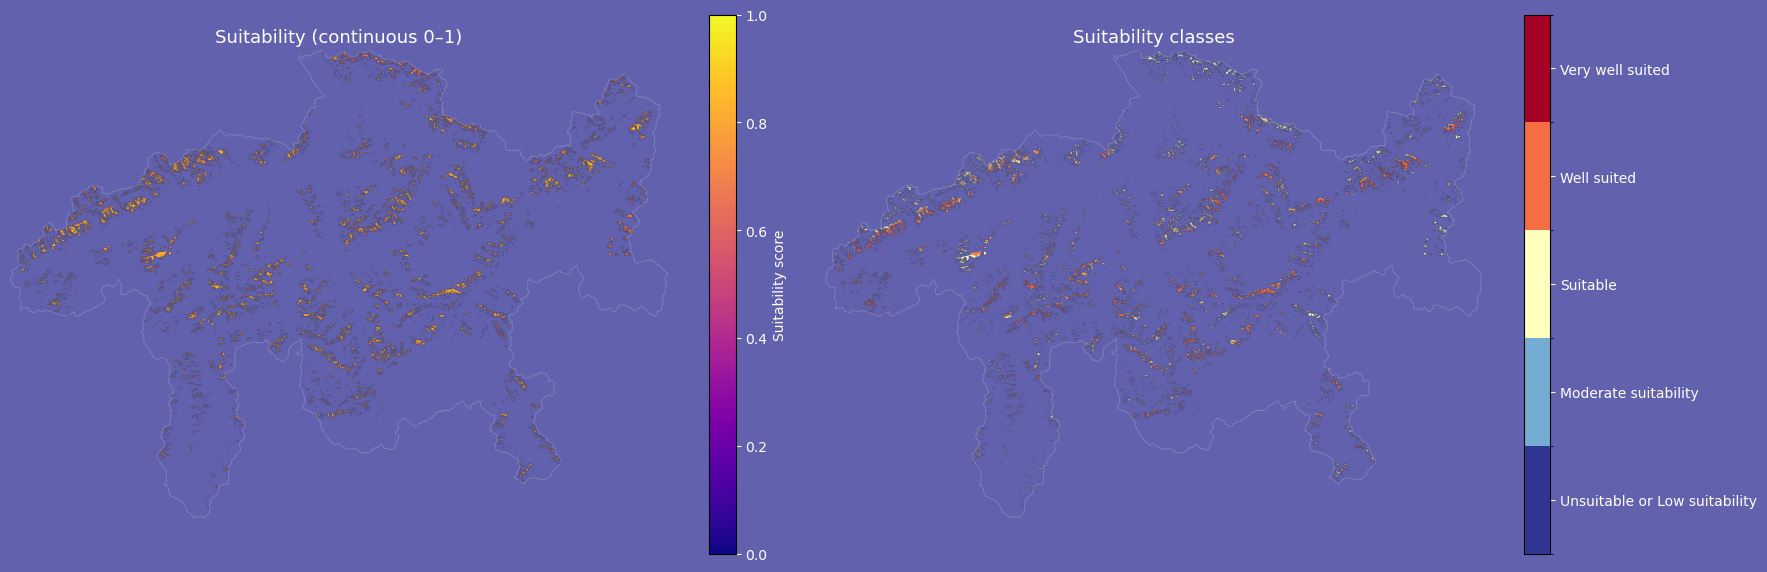

  ✓ ..\outputs\figures\suitability_map.png


In [8]:
# Map creation
plot_suitability(
    suitability, classified, CLASSES,
    valid, NODATA, transform,
    OUT / "figures/suitability_map.png"
)

## 9. Safe Output

In [9]:
print("=== Saving Outputs ===\n")

#Continuous suitability raster
save_raster(suitability, OUT / "suitability_wlc.tif", ref_profile,
            dtype="float32", nodata_val=NODATA)

# Classified suitability raster
save_raster(classified, OUT / "suitability_classes.tif", ref_profile,
            dtype="uint8", nodata_val=0)

# Statistics table
stats.to_csv(OUT / "tables/suitability_stats.csv", index=False)            # CSV-Export
print(f"  ✓ {OUT / 'tables/suitability_stats.csv'}")

print("\n=== Fertig ===")

=== Saving Outputs ===

  ✓ ..\outputs\suitability_wlc.tif
  ✓ ..\outputs\suitability_classes.tif
  ✓ ..\outputs\tables\suitability_stats.csv

=== Fertig ===


## Next Step

The suitability map (`suitability_wlc.tif`) and classes (`suitability_classes.tif`) can be combined with a political acceptance layer.

**→ Continue with:** Sensitivity analysis / Validation